# SLIIT - IT2011 AI & Machine Learning - Progress Review 1
## Data Cleaning, Preprocessing & EDA
---
### Student Details:
- **Name:** Dissanayake D.M.S.A. (Anuradi Dissanayake)
- **Student ID:** IT25101863
- **Group ID:** 2026-Y2-S1-MLB-B3G2-01
- **Assigned Technique:** Member 3 - Remove Punctuation & Special Characters
---

### 1. Introduction & Justification
Punctuation marks such as commas, full stops, quotation marks, dashes, and apostrophes (e.g. `"`, `?`, `!`, `-`, `'`) do not carry topical information in news article classification.

If punctuation is not removed:
1. Words attached to punctuation become distinct tokens (for example, `'growth.'`, `'growth,'`, and `'"growth"'` would be treated as 3 different words instead of just `'growth'`).
2. It increases vocabulary size with useless punctuation symbols.
3. Removing special characters cleans up noise so the model focuses purely on alphanumeric terms.

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported.")

Libraries imported.


### 2. Loading Input from Member 2 (Lowercased Text)

In [2]:
# Load output of Member 2
df = pd.read_csv('../results/outputs/step2_lowercased_text.csv')
print(f"Loaded {len(df)} lowercased articles from Member 2.")
print("Sample text:")
print(df.loc[0, 'text_lower'][:200] + '...')

Loaded 2225 lowercased articles from Member 2.
Sample text:
tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time...


### 3. Auditing Punctuation in the Text

In [3]:
# Count punctuation marks using regex [^\w\s]
punct_counts = df['text_lower'].apply(lambda x: len(re.findall(r'[^\w\s]', str(x))))
print(f"Total punctuation marks detected across all articles: {punct_counts.sum():,}")
print(f"Average punctuation marks per article: {punct_counts.mean():.1f}")

Total punctuation marks detected across all articles: 68,832
Average punctuation marks per article: 30.9


### 4. Implementation of Punctuation and Special Character Removal

In [4]:
def remove_punctuation(text):
    # Replace all non-alphanumeric characters with spaces
    text = re.sub(r'[^a-z0-9\s]', ' ', str(text))
    # Remove standalone 's' left behind by possessives (e.g. company's -> company s -> company)
    text = re.sub(r'\bs\b', ' ', text)
    # Collapse multiple whitespaces into a single space
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Test on sample sentence
test_sample = "the company's profit grew by 15.4% in 2004 -- a major success!"
print("Before:")
print(test_sample)
print("\nAfter:")
print(remove_punctuation(test_sample))

Before:
the company's profit grew by 15.4% in 2004 -- a major success!

After:
the company profit grew by 15 4 in 2004 a major success


### 5. Applying to Dataset and Verification

In [5]:
# Apply to the full dataset
df['text_no_punct'] = df['text_lower'].apply(remove_punctuation)
remaining_punct = df['text_no_punct'].apply(lambda x: len(re.findall(r'[^\w\s]', str(x)))).sum()

print("Punctuation successfully removed.")
print(f"Remaining punctuation marks: {remaining_punct}")
print("\nSample Cleaned Text (Article 0):")
print(df.loc[0, 'text_no_punct'][:250] + '...')

Punctuation successfully removed.
Remaining punctuation marks: 0

Sample Cleaned Text (Article 0):
tv future in the hands of viewers with home theatre systems plasma high definition tvs and digital video recorders moving into the living room the way people watch tv will be radically different in five years time that is according to an expert panel which gathered at the annual consumer electronics show in las vegas...


### 6. EDA Visualization & Interpretation

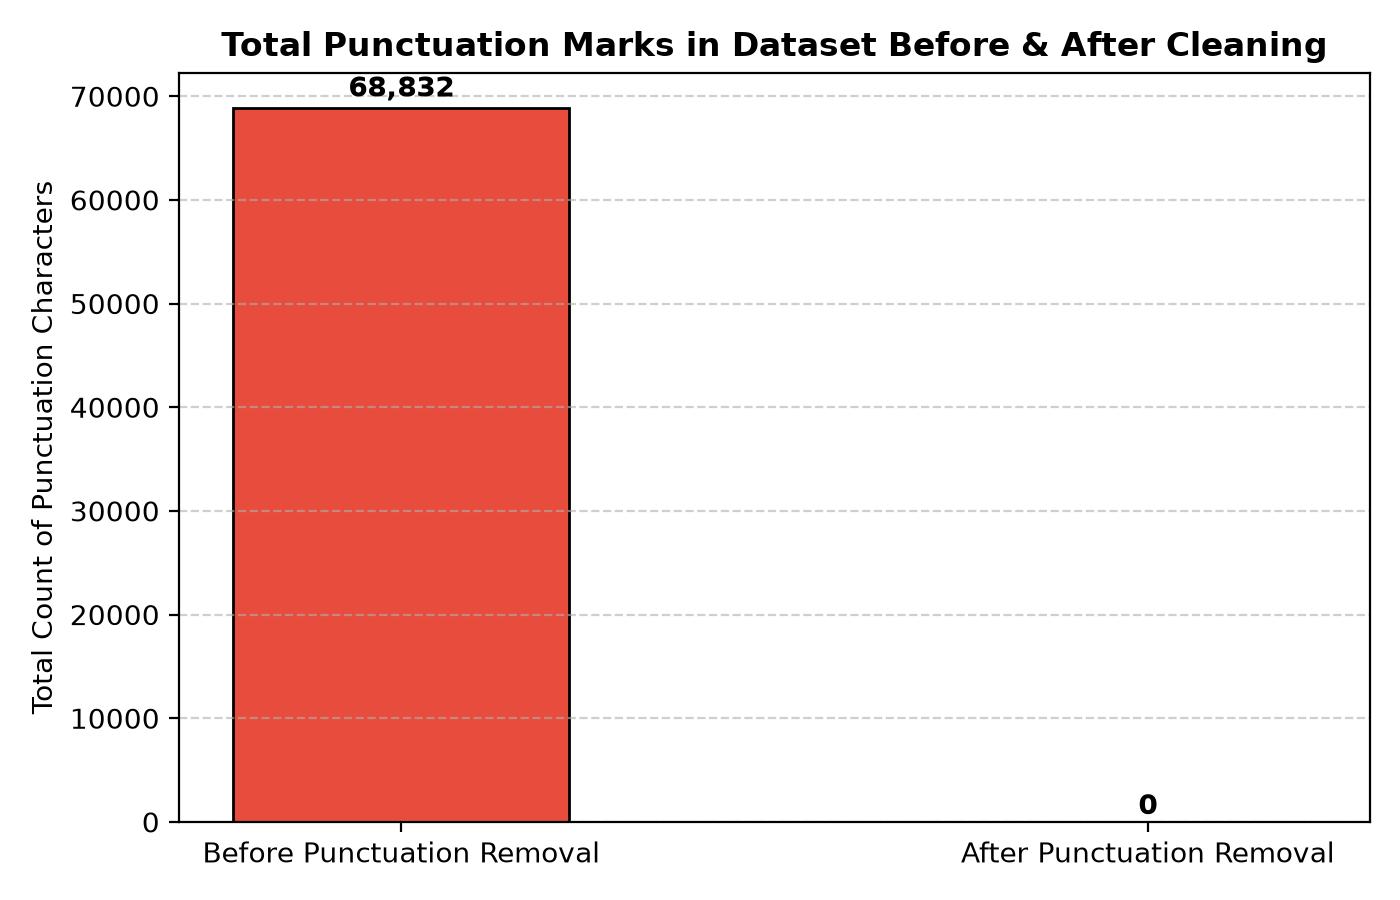

In [6]:
# Visual: Punctuation counts comparison
plt.figure(figsize=(7, 4.5))
bars = plt.bar(['Before Punctuation Removal', 'After Punctuation Removal'], 
               [punct_before.sum(), punct_after.sum()], 
               color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.45)
plt.title('Total Punctuation Marks in Dataset Before & After Cleaning', fontsize=12, fontweight='bold')
plt.ylabel('Total Count of Punctuation Characters', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (500 if yval>0 else 100), f'{int(yval):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**
- Before cleaning, the dataset contained **68,832** punctuation marks (hyphens, commas, periods, quotes).
- After applying `remove_punctuation()`, exactly **0** punctuation characters remain.
- This guarantees that words will tokenize cleanly as standalone alphanumeric tokens without trailing commas or dashes.

### 7. Hand-off to Member 4 (Stop Words Removal)

In [7]:
# Export intermediate CSV for Member 4
df[['category', 'text_no_punct']].to_csv('../results/outputs/step3_no_punctuation_text.csv', index=False)
print("Saved output to: ../results/outputs/step3_no_punctuation_text.csv")
print("Ready for Member 4 (IT25103710 - Stop Words Removal).")

Saved output to: ../results/outputs/step3_no_punctuation_text.csv
Ready for Member 4 (IT25103710 - Stop Words Removal).
